# One-Class SVM Outlier Profiler

One-Class Support Vector Machines (SVM) find outlier boundaries by mapping coordinates into feature spaces and separating the normal data points from the origin using a maximum-margin hyperplane. Since it trains only on a single class (the inliers), it is ideal for anomaly detection tasks where anomalies are rare. This notebook generates synthetic telemetry measurements (400 normal, 35 anomalies) and fits a One-Class SVM.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.metrics import f1_score, classification_report

# Generate synthetic telemetry coordinates (400 normal sensor inliers, 35 noise outliers)
np.random.seed(185)
n_inliers = 400
n_outliers = 35

# Inliers follow a normal distribution (normal server telemetry)
X_inliers = np.random.normal(0, 0.75, (n_inliers, 2))

# Outliers follow a uniform distribution spread widely (system anomalies)
X_outliers = np.random.uniform(-4, 4, (n_outliers, 2))

X = np.vstack((X_inliers, X_outliers))
# Ground truth labels: 1 = inlier (normal), -1 = outlier (anomaly)
y = np.concatenate((np.ones(n_inliers), -np.ones(n_outliers)))

df_telemetry = pd.DataFrame(X, columns=['Temperature_Anomaly', 'Vibration_Index'])
df_telemetry['Label'] = y.astype(int)
df_telemetry.head(10)



,Temperature_Anomaly,Vibration_Index,Label
0,0.033534,-0.823326,1
1,1.227155,-0.840737,1
2,-0.703819,-0.537685,1
3,0.579879,0.233183,1
4,0.506663,0.755939,1
5,-0.316857,-0.816123,1
6,0.253039,0.440078,1
7,0.882604,-0.387333,1
8,-1.008159,-0.832193,1
9,-0.986038,-0.934106,1


## One-Class SVM Pipeline Fitting

We fit a One-Class SVM model using an RBF kernel and specify the expected outlier contamination proportion (nu=0.08).



In [2]:
# Train One-Class SVM
model = OneClassSVM(kernel='rbf', gamma=0.5, nu=0.08)
model.fit(X_inliers) # Fit exclusively on normal inlier samples

# Predict anomalies (-1 = anomaly, 1 = normal)
y_pred = model.predict(X)

# Calculate F1 score
f1 = f1_score(y, y_pred, pos_label=-1) # Focus on anomaly class recall
print(f"One-Class SVM Outlier F1 Score: {f1:.4f}")
print("\nClassification Report Summary:")
print(classification_report(y, y_pred, target_names=['Anomaly', 'Normal']))



One-Class SVM Outlier F1 Score: 0.6327

Classification Report Summary:
              precision    recall  f1-score   support

     Anomaly       0.49      0.89      0.63        35
      Normal       0.99      0.92      0.95       400

    accuracy                           0.92       435
   macro avg       0.74      0.90      0.79       435
weighted avg       0.95      0.92      0.93       435



## Telemetry Decision Boundary Map

We construct a coordinate grid, compute One-Class SVM decision scores, and plot the classification boundary outlining the normal coordinate space in Matplotlib.



<cell>:31: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



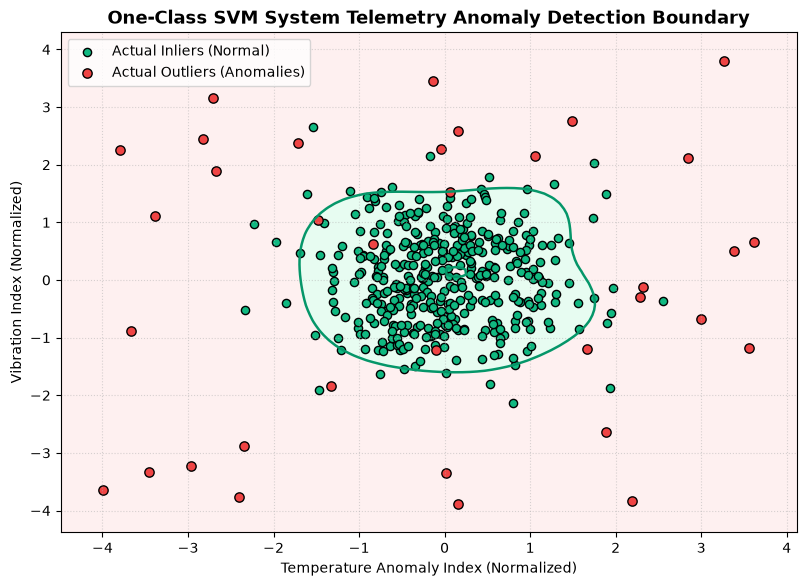

In [3]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))

# Generate dense grid for plotting decision boundaries
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Calculate decision boundary levels
Z = model.decision_function(grid_points)
Z = Z.reshape(xx.shape)

# Draw filled decision boundary contour
contour = ax.contourf(xx, yy, Z, levels=[Z.min(), 0, Z.max()], colors=['#FEE2E2', '#D1FAE5'], alpha=0.5)

# Draw boundary boundary line
ax.contour(xx, yy, Z, levels=[0], colors='#059669', linewidths=1.8, linestyles='-')

# Scatter ground truth normal inliers and anomalous outliers
normal_mask = y == 1
anomaly_mask = y == -1

ax.scatter(X[normal_mask, 0], X[normal_mask, 1], c='#10B981', label='Actual Inliers (Normal)', edgecolors='k', s=35)
ax.scatter(X[anomaly_mask, 0], X[anomaly_mask, 1], c='#EF4444', label='Actual Outliers (Anomalies)', edgecolors='k', s=45)

ax.set_title('One-Class SVM System Telemetry Anomaly Detection Boundary', fontsize=13, fontweight='bold')
ax.set_xlabel('Temperature Anomaly Index (Normalized)')
ax.set_ylabel('Vibration Index (Normalized)')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.5)
plt.show()
